# Decision Trees and Random Forests

## Introduction

**Decision Trees** and **Random Forests** are among the most widely used machine learning algorithms in practice. They are non-parametric, require minimal feature preprocessing, handle mixed feature types naturally, and are highly interpretable (for shallow trees).

### Why Trees?

Unlike linear models, decision trees can capture **non-linear** and **interaction** effects without feature engineering. A tree partitions the feature space into axis-aligned rectangles and assigns a prediction to each region.

### Why Random Forests?

A single decision tree is unstable: small changes in training data can lead to very different trees (high variance). Random forests address this by averaging many independently-trained trees — each on a **bootstrap sample** and with **random feature subsets** — dramatically reducing variance while keeping bias low.

### Learning Objectives
1. Understand the CART algorithm: how decision trees find splits
2. Understand decision tree overfitting and its relationship to depth
3. Understand bagging: why averaging reduces variance
4. Understand random forests: adding feature randomness to decorrelate trees
5. Apply random forests for both classification and regression
6. Interpret feature importance from a random forest

## Notation

| Symbol | Meaning |
|--------|---------|
| $m$ | Number of training samples |
| $n$ | Number of features |
| $\mathbf{x}^{(i)} \in \mathbb{R}^n$ | $i$-th training example |
| $y^{(i)}$ | $i$-th target label |
| $t$ | A tree node (internal or leaf) |
| $S_t$ | Set of samples reaching node $t$ |
| $\mathcal{I}(S)$ | Impurity of sample set $S$ |
| $B$ | Number of trees in the ensemble |
| $m_{\text{try}}$ | Number of features sampled per split (RF parameter) |
| $\hat{f}^{(b)}$ | $b$-th tree in the ensemble |

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from ipywidgets import interact


def visualize_tree(estimator, X, y, boundaries=True,
                   xlim=None, ylim=None, ax=None):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()

    # fit the estimator
    estimator.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    n_classes = len(np.unique(y))
    Z = Z.reshape(xx.shape)
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='viridis', clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

    # Plot the decision boundaries
    def plot_boundaries(i, xlim, ylim):
        if i >= 0:
            tree = estimator.tree_

            if tree.feature[i] == 0:
                ax.plot([tree.threshold[i], tree.threshold[i]], ylim, '-k', zorder=2)
                plot_boundaries(tree.children_left[i],
                                [xlim[0], tree.threshold[i]], ylim)
                plot_boundaries(tree.children_right[i],
                                [tree.threshold[i], xlim[1]], ylim)

            elif tree.feature[i] == 1:
                ax.plot(xlim, [tree.threshold[i], tree.threshold[i]], '-k', zorder=2)
                plot_boundaries(tree.children_left[i], xlim,
                                [ylim[0], tree.threshold[i]])
                plot_boundaries(tree.children_right[i], xlim,
                                [tree.threshold[i], ylim[1]])

    if boundaries:
        plot_boundaries(0, xlim, ylim)


def plot_tree_interactive(X, y):
    def interactive_tree(depth=5):
        clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
        visualize_tree(clf, X, y)

    return interact(interactive_tree, depth=[1, 3, 5, 7])


def randomized_tree_interactive(X, y):
    N = int(0.75 * X.shape[0])

    xlim = (X[:, 0].min(), X[:, 0].max())
    ylim = (X[:, 1].min(), X[:, 1].max())

    def fit_randomized_tree(random_state=0):
        clf = DecisionTreeClassifier(max_depth=15)
        i = np.arange(len(y))
        rng = np.random.RandomState(random_state)
        rng.shuffle(i)
        visualize_tree(clf, X[i[:N]], y[i[:N]], boundaries=False,
                       xlim=xlim, ylim=ylim)

    interact(fit_randomized_tree, random_state=[0, 100]);

def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

ModuleNotFoundError: No module named 'numpy'

## Motivating Random Forests: Decision Trees

## The CART Algorithm: How Trees Are Built

**CART (Classification and Regression Trees)** greedily builds a binary tree by recursively finding the best split at each node.

### Splitting Criterion

At each node $t$ containing sample set $S_t$, we search over all features $j$ and thresholds $\theta$ to find the split that most reduces **impurity**:

$$\text{Gain}(S_t, j, \theta) = \mathcal{I}(S_t) - \frac{|S_L|}{|S_t|}\mathcal{I}(S_L) - \frac{|S_R|}{|S_t|}\mathcal{I}(S_R)$$

where $S_L = \{\mathbf{x} \in S_t : x_j \leq \theta\}$ and $S_R = \{\mathbf{x} \in S_t : x_j > \theta\}$.

### Impurity Measures

**For classification:**

| Metric | Formula | Notes |
|--------|---------|-------|
| **Gini impurity** | $\mathcal{I}_G = 1 - \sum_{k=1}^K p_k^2$ | Default in sklearn |
| **Entropy (info gain)** | $\mathcal{I}_H = -\sum_{k=1}^K p_k \log_2 p_k$ | Equivalent in practice |

where $p_k = |\{i \in S_t : y^{(i)} = k\}| / |S_t|$ is the fraction of class $k$ in node $t$.

**For regression:**

$$\mathcal{I}_{\text{MSE}} = \frac{1}{|S_t|}\sum_{i \in S_t}(y^{(i)} - \bar{y}_t)^2, \quad \bar{y}_t = \frac{1}{|S_t|}\sum_{i \in S_t} y^{(i)}$$

### Prediction

- **Classification:** majority class in the leaf
- **Regression:** mean target value in the leaf

### Stopping Criteria (Regularisation)

A fully grown tree has zero training error but severe overfitting. Common stopping conditions:
- `max_depth`: maximum depth of the tree
- `min_samples_leaf`: minimum samples in any leaf
- `min_samples_split`: minimum samples required to split a node
- `max_leaf_nodes`: maximum number of leaves
- `min_impurity_decrease`: only split if impurity decreases by at least this amount

### Computational Complexity

Finding the best split at a node with $|S_t|$ samples and $n$ features requires evaluating $O(n \cdot |S_t| \log |S_t|)$ possible splits (sort each feature). Building the full tree is $O(n \cdot m \log m)$.

### Why Decision Trees Are Intuitive

Decision trees classify by asking a sequence of binary questions about the features, narrowing down possibilities at each step. Formally:

$$h(\mathbf{x}) = \sum_{\ell=1}^{L} c_\ell \cdot \mathbf{1}[\mathbf{x} \in R_\ell]$$

where $R_1, \ldots, R_L$ are the disjoint rectangular leaf regions that partition the feature space, and $c_\ell$ is the prediction for region $R_\ell$.

**Key properties:**
- Invariant to monotone feature transformations (no need to standardise)
- Handles missing values natively (surrogate splits)
- Mixed feature types (categorical + continuous)
- Easily visualised and interpreted (white-box model)

**Key weakness:** High variance — a tree's structure changes dramatically with small perturbations to the training data. This motivates ensemble methods.

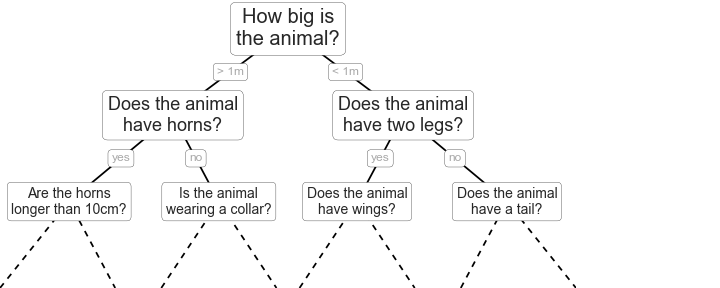

The binary splitting makes this extremely efficient: in a well-constructed tree, each question will cut the number of options by as much as possible, very quickly narrowing the options even among a large number of classes.
The trick, of course, comes in deciding which questions to ask at each step.
In machine learning implementations of decision trees, each node in the tree splits the data into two groups using a cutoff value within one of the features.
Let's now look at an example of this.

### Decision Trees in 2D: Axis-Aligned Boundaries

Decision trees partition the feature space with **axis-aligned** splits: each decision is of the form "$x_j \leq \theta$". The resulting decision boundary is a collection of axis-aligned rectangles.

Let us visualise how the boundary changes with tree depth:

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow', edgecolors='white', linewidths=0.4)
plt.colorbar(scatter, label='Class')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset: 4-Class Blob Classification')
plt.tight_layout()
plt.show()

A simple decision tree built on this data will iteratively split the data along one or the other axis according to some quantitative criterion, and at each level assign the label of the new region according to a majority vote of points within it.
This figure presents a visualization of the first four levels of a decision tree classifier for this data:

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(16, 3))
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)

for axi, depth in zip(ax, range(4, 13, 2)):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    visualize_tree(model, X, y, ax=axi)
    axi.set_title(f'depth = {depth}', fontsize=11)

fig.suptitle('Decision Tree: Effect of Max Depth on Decision Boundary', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Notice that after the first split, every point in the upper branch remains unchanged, so there is no need to further subdivide this branch.
Except for nodes that contain all of one color, at each level *every* region is again split along one of the two features.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

Now we can examine what the decision tree classification looks like:

In [ ]:
visualize_classifier(DecisionTreeClassifier(), X, y)

In [ ]:
plot_tree_interactive(X, y);

As depth increases, the tree creates increasingly **fine-grained partitions** that fit the training data more closely. With unlimited depth, the tree will eventually create a separate leaf for almost every training point — achieving zero training error but generalising poorly.

**This is exactly the overfitting phenomenon:**
- Deep tree → low training error, high test error (high variance)  
- Shallow tree → higher training error, potentially lower test error (lower variance, higher bias)

### Decision Trees and Overfitting

An unconstrained decision tree is the prototypical **high-variance, low-bias** model. We can demonstrate this instability by training on two different halves of the data:

In [ ]:
model = DecisionTreeClassifier(random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
visualize_tree(model, X[::2],  y[::2],  boundaries=False, ax=ax[0])
visualize_tree(model, X[1::2], y[1::2], boundaries=False, ax=ax[1])
ax[0].set_title('Tree trained on even-indexed samples', fontsize=11)
ax[1].set_title('Tree trained on odd-indexed samples',  fontsize=11)
fig.suptitle('Decision Tree Instability: Same Data, Different Split → Different Boundaries',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

The two trees (trained on disjoint halves of the data) agree in easy regions (far from cluster boundaries) but disagree wildly in ambiguous regions.

**Root cause:** each split in a deep tree can be "locked in" by just a few training samples in that region. Different random samples → different splits → very different boundaries.

**Insight:** If only we could average many such trees, the variance would decrease while the aggregate bias stays low. This is the core idea of **bagging**.

## Ensembles of Estimators: From Bagging to Random Forests

### Bagging (Bootstrap Aggregating)

**Key theorem:** If $\hat{f}^{(1)}, \ldots, \hat{f}^{(B)}$ are i.i.d. with variance $\sigma^2$ and pairwise correlation $\rho$, then the variance of their average is:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^B \hat{f}^{(b)}\right) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, the second term vanishes: **variance $\to \rho\sigma^2$**.

**Bagging** reduces variance by making the trees more independent:
- Train $B$ trees on **bootstrap samples** (sample $m$ points with replacement)
- For regression: average predictions; for classification: majority vote

**Limitation of pure bagging:** the trees are highly correlated ($\rho$ is large) because they all use all $n$ features and likely pick the same dominant feature at the root.

### Random Forests: Decorrelating the Trees

Random Forests (Breiman, 2001) reduce $\rho$ further by adding **random feature subsampling**:

> At each split, consider only $m_{\text{try}}$ randomly chosen features (instead of all $n$).

Common choices:
- **Classification:** $m_{\text{try}} = \lfloor\sqrt{n}\rfloor$
- **Regression:** $m_{\text{try}} = \lfloor n/3 \rfloor$

This prevents all trees from always splitting on the strongest feature, forcing each tree to find complementary patterns. The trees are less correlated ($\rho$ decreases), so the ensemble variance is lower.

**Bias-Variance of Random Forests:**
- Bias ≈ bias of a single deep tree (low)
- Variance ≈ $\rho\sigma^2$ (reduced by decorrelation)

As $B \to \infty$, RF variance converges — there is a limit to how much adding more trees helps, set by $\rho\sigma^2$.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier(random_state=42)
bag  = BaggingClassifier(tree, n_estimators=200, max_samples=0.8, random_state=1)
bag.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
visualize_classifier(bag, X, y, ax=ax)
ax.set_title('Bagging Classifier (200 trees, 80% bootstrap)', fontsize=11)
plt.tight_layout()
plt.show()

In this example, **bagging** already smooths the decision boundary compared to a single tree. `max_samples=0.8` means each tree is trained on 80% of the data (sample without replacement in this case — for true bootstrap, set `bootstrap=True`).

Note how the boundary is smoother and more regular — individual tree quirks average out.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X, y)

fig, ax = plt.subplots(figsize=(6, 5))
visualize_classifier(model, X, y, ax=ax)
ax.set_title('Random Forest Classifier (100 trees)', fontsize=11)
plt.tight_layout()
plt.show()

With 100 trees, each trained on a bootstrap sample and with random feature subsets, the ensemble decision boundary is smooth, regular, and closely matches the true Gaussian cluster structure.

**Out-of-bag (OOB) error:** Since each tree is trained on ~63% of the data (bootstrap leaves ~37% out-of-bag), we can evaluate each tree on the samples it didn't see. Averaging these OOB errors gives a built-in validation estimate without a separate validation set.

## Random Forest Regression

Random forests work equally well for regression. The prediction is the **average** of all tree predictions (instead of majority vote):

$$\hat{f}_{\text{RF}}(\mathbf{x}) = \frac{1}{B}\sum_{b=1}^B \hat{f}^{(b)}(\mathbf{x})$$

We demonstrate on a 1D function with multiple periodicities: $y = \sin(\pi x) + \sin(0.2x) + \varepsilon$. This is non-stationary (no single polynomial or linear model fits well), so a flexible non-parametric method like RF is ideal.

In [ ]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(np.pi * x)
    slow_oscillation = np.sin(0.2 * x)
    noise = sigma * rng.randn(len(x))
    return slow_oscillation + fast_oscillation + noise

y = model(x)

plt.figure(figsize=(9, 4))
plt.errorbar(x, y, yerr=0.3, fmt='o', alpha=0.5, color='steelblue',
             ecolor='lightblue', capsize=2, label='Noisy observations')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression Dataset: Noisy Sum-of-Sines')
plt.legend()
plt.tight_layout()
plt.show()

Using the random forest regressor, we can find the best fit curve as follows:

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100, random_state=42)
forest.fit(x[:, None], y)

xfit  = np.linspace(0, 10, 1000)
yfit  = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.figure(figsize=(9, 4))
plt.errorbar(x, y, yerr=0.3, fmt='o', alpha=0.4, color='steelblue',
             ecolor='lightblue', capsize=2, label='Noisy data')
plt.plot(xfit, yfit,  '-r',  linewidth=2, label='RF prediction (100 trees)')
plt.plot(xfit, ytrue, '--k', linewidth=1.5, alpha=0.6, label='True signal (no noise)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Forest Regression')
plt.legend()
plt.tight_layout()
plt.show()

The red RF prediction closely tracks the true function (grey), capturing both the fast oscillation $\sin(\pi x)$ and the slow oscillation $\sin(0.2x)$.

**Key observation:** The RF automatically adapts its local resolution — it uses more leaf regions in areas with rapid change and fewer in smooth areas. No polynomial degree or bandwidth had to be specified.

## Feature Importance in Random Forests

Random forests provide a natural measure of **feature importance** by tracking how much each feature contributes to reducing impurity across all trees.

### Mean Decrease in Impurity (MDI)

For feature $j$, the MDI importance is:

$$\text{Importance}(j) = \frac{1}{B}\sum_{b=1}^B \sum_{t \in T_b : \text{split on } j} |S_t| \cdot \text{Gain}(S_t, j, \theta_t^*)$$

averaged and normalised across all trees. This is fast to compute (during training) but can be **biased towards high-cardinality features**.

### Permutation Importance (more reliable)

1. Compute baseline validation score
2. For each feature $j$: randomly shuffle feature $j$ in the validation set, compute new score
3. Importance = decrease in score

This measures *how much the model relies on each feature* rather than how often it was used.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# Use Iris dataset for feature importance demo
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42)

rf_iris = RandomForestClassifier(n_estimators=200, random_state=42, oob_score=True)
rf_iris.fit(X_tr_iris, y_tr_iris)

print(f"Test accuracy:  {rf_iris.score(X_te_iris, y_te_iris):.4f}")
print(f"OOB accuracy:   {rf_iris.oob_score_:.4f}  (no validation set needed!)")

# MDI importance
mdi_imp = rf_iris.feature_importances_

# Permutation importance
perm = permutation_importance(rf_iris, X_te_iris, y_te_iris,
                               n_repeats=30, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.barh(iris.feature_names, mdi_imp, color='steelblue')
ax1.set_xlabel('MDI Importance'); ax1.set_title('Mean Decrease in Impurity (MDI)')
ax1.grid(alpha=0.3)

ax2.boxplot(perm.importances.T, vert=False, labels=iris.feature_names)
ax2.set_xlabel('Decrease in accuracy'); ax2.set_title('Permutation Importance')
ax2.grid(alpha=0.3)

plt.suptitle('Feature Importance: Iris Dataset', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("\nMDI Importances:", dict(zip(iris.feature_names, mdi_imp.round(3))))

## Summary: Decision Trees and Random Forests

### Decision Trees

| Property | Value |
|----------|-------|
| Type | Non-parametric, recursive partitioning |
| Split criterion | Gini / Entropy (classification); MSE (regression) |
| Key hyperparameter | `max_depth`, `min_samples_leaf` |
| Bias-Variance | Low bias, **high variance** |
| Interpretability | **Excellent** (visualisable) |
| Feature scaling | Not needed |
| Multiclass | Native |
| Missing values | Handled (surrogate splits) |

### Random Forests

| Property | Value |
|----------|-------|
| Type | Ensemble of decision trees |
| Aggregation | Majority vote (class) / Average (regression) |
| Key hyperparameters | `n_estimators`, `max_features` ($m_{\text{try}}$), `max_depth` |
| Bias-Variance | Low bias, **low variance** |
| Interpretability | Feature importance (opaque individual trees) |
| Parallelisable | **Yes** (trees are independent) |
| OOB estimate | Free validation without separate val set |

### When to Choose Random Forest vs. Gradient Boosting

| Criterion | Random Forest | Gradient Boosting (XGBoost) |
|-----------|--------------|----------------------------|
| Training speed | Faster (parallel) | Slower (sequential) |
| Hyperparameter sensitivity | Low | Higher |
| Accuracy | Good | Often better |
| Overfitting risk | Lower | Higher (needs early stopping) |
| Feature importance | Reliable | Also reliable (gain, SHAP) |

## Reflection Questions

1. **CART split criterion.** Prove that for binary classification with $p$ fraction of positives, the Gini impurity is $2p(1-p)$ and the entropy is $-p\log_2 p - (1-p)\log_2(1-p)$. Both are maximised at $p=0.5$ and minimised at $p \in \{0,1\}$. Why does this make them suitable split criteria?

2. **Bias-variance of bagging.** Starting from the variance formula $\text{Var}\left(\frac{1}{B}\sum_b \hat{f}^{(b)}\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$:
   - What happens as $B \to \infty$? What is the limiting variance?
   - How does random feature subsampling reduce $\rho$?
   - If $\rho = 0.85$ and $\sigma^2 = 1$, how many trees are needed to reduce variance to within 5% of the $B \to \infty$ limit?

3. **OOB error.** Each bootstrap sample includes $\approx 63.2\%$ of the training points (the rest are out-of-bag). Derive this: what is $P(\text{not selected})$ for one point over $m$ draws with replacement?

4. **Feature importance limitations.** MDI importance is biased towards high-cardinality features (e.g., a feature with many unique values is split more often). How does permutation importance avoid this bias? What is permutation importance's limitation (hint: correlated features)?

5. **Comparison with gradient boosting.** Both Random Forests and XGBoost are ensemble tree methods, but they differ in how they combine trees. Explain the difference between parallel (bagging) and sequential (boosting) ensembles in terms of: (a) what each tree is trained on; (b) what error each method primarily reduces; (c) sensitivity to the number of trees.

## Answers to Reflection Questions

**1. Gini and entropy as split criteria.**
For binary classification with fraction $p$ of positives:
- Gini: $1 - p^2 - (1-p)^2 = 2p(1-p)$. Max at $p=0.5$: $2(0.5)(0.5)=0.5$. Zero at $p \in \{0,1\}$. ✓
- Entropy: $-p\log_2 p - (1-p)\log_2(1-p)$. Max at $p=0.5$: $-2(0.5)\log_2(0.5) = 1$ bit. Zero at $p \in \{0,1\}$ ($0\log 0 = 0$ by convention). ✓

Both measure **impurity** — how mixed the classes are. A node with all-one class has zero impurity (perfect predictions); a 50/50 node has maximum impurity. The information gain from a split is the decrease in impurity, so we pick the split that creates the most homogeneous children.

---

**2. Variance reduction of bagging.**
As $B \to \infty$: variance $\to \rho\sigma^2$ (the second term $\frac{1-\rho}{B}\sigma^2 \to 0$). The irreducible ensemble variance is $\rho\sigma^2$ — set by pairwise tree correlation.

Random feature subsampling: if the dominant feature is unavailable at some splits, different trees are forced to use different features → lower pairwise correlation $\rho$ → lower limiting variance.

For $\rho=0.85, \sigma^2=1$: limiting variance $= 0.85$. We want $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2 \leq 0.85 \times 1.05 = 0.8925$. Solving: $\frac{0.15}{B} \leq 0.0425 \Rightarrow B \geq \lceil 0.15/0.0425 \rceil = 4$ trees. So variance converges quickly with small $B$ for large $\rho$.

---

**3. OOB error derivation.**
Each bootstrap sample of $m$ draws (with replacement) from $m$ points. The probability that a specific point is **not** selected in any draw:
$$P(\text{not in sample}) = \left(1 - \frac{1}{m}\right)^m \xrightarrow{m \to \infty} e^{-1} \approx 0.368$$
So ~36.8% of points are out-of-bag for each tree. Averaging predictions over all trees that didn't see a given point gives the OOB estimate — approximately equivalent to a 1/0.368 ≈ 2.7-fold cross-validation.

---

**4. MDI vs. permutation importance.**
MDI counts impurity reduction at splits, which is **biased** toward high-cardinality features: a numerical feature with $k$ unique values offers $k-1$ candidate thresholds vs. 1 for a binary feature — more opportunities to find a good split by chance. **Permutation importance** directly measures the effect on held-out predictions, bypassing the split-counting mechanism, so it is unbiased w.r.t. cardinality.

Permutation importance's limitation: if two features are highly correlated (e.g., height in cm and height in inches), permuting one leaves the model able to use the other as a substitute. Both features appear unimportant despite being genuinely informative. **SHAP** handles correlated features better by marginalising over all feature coalitions.

---

**5. Parallel vs. sequential ensembles.**
(a) *What each tree is trained on:* RF trains each tree on an independent bootstrap sample of the full dataset. Boosting trains each tree on the **pseudo-residuals** (errors) of the current ensemble — a dataset derived from previous trees.  
(b) *Primary error reduced:* RF reduces **variance** (averaging uncorrelated trees). Boosting reduces **bias** (each tree corrects the ensemble's systematic errors).  
(c) *Sensitivity to number of trees:* RF plateaus — adding trees beyond ~200-500 rarely helps. Boosting overfit with too many trees — the ensemble memorises noise from the residuals. Early stopping is essential for boosting; for RF, more trees never hurt (only waste compute).